# NLP de comentarios de Menéame

Limpieza, clasificación y análisis temporal de los comentarios sobre inmigración y LGTBI.

In [2]:
#!pip install pysentimiento
#!pip install bertopic
#!pip install sentence-transformers
#!pip install umap-learn
#!pip install hdbscan
#!pip install wordcloud

# Bloque 1 · Configuración del entorno

In [1]:
# ============================
# LIBRERÍAS
# ============================

from pathlib import Path
import re
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from pysentimiento import create_analyzer

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

from umap import UMAP
from hdbscan import HDBSCAN

from tqdm.auto import tqdm

c:\Users\herre\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\herre\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# ============================
# RUTAS
# ============================

from pathlib import Path

BASE = Path(
    r"C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13"
)

RUTA_RAW = (
    BASE
    / "01_data"
    / "01_raw"
    / "rrss"
    / "meneame"
)

RUTA_PROCESADOS = (
    BASE
    / "01_data"
    / "02_processed"
    / "rrss"
    / "meneame"
)

RUTA_TABLAS = (
    BASE
    / "03_outputs"
    / "tables"
    / "rrss"
    / "meneame"
)

RUTA_GRAFICOS = (
    BASE
    / "03_outputs"
    / "figures"
    / "rrss"
    / "meneame"
)

RUTA_DICCIONARIOS = (
    BASE
    / "scripts"
    / "diccionarios"
)

for ruta in [
    RUTA_RAW,
    RUTA_PROCESADOS,
    RUTA_TABLAS,
    RUTA_GRAFICOS
]:
    ruta.mkdir(
        parents=True,
        exist_ok=True
    )

print("RAW:", RUTA_RAW)
print("PROCESADOS:", RUTA_PROCESADOS)
print("Existe PROCESADOS:", RUTA_PROCESADOS.exists())
print("TABLAS:", RUTA_TABLAS)
print("GRÁFICOS:", RUTA_GRAFICOS)

RAW: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\01_raw\rrss\meneame
PROCESADOS: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\02_processed\rrss\meneame
Existe PROCESADOS: True
TABLAS: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\03_outputs\tables\rrss\meneame
GRÁFICOS: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\03_outputs\figures\rrss\meneame


# Bloque 2 · Carga y preparación de los datos

In [4]:
archivo_comentarios = (
    RUTA_PROCESADOS
    / "meneame_comentarios_limpios.csv"
)

print("Archivo:", archivo_comentarios)
print("Existe:", archivo_comentarios.exists())

comentarios = pd.read_csv(
    archivo_comentarios
)

Archivo: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\02_processed\rrss\meneame\meneame_comentarios_limpios.csv
Existe: True


In [5]:
ANIOS_ANALISIS = [
    2015,
    2016,
    2019,
    2023
]

print("Años antes del filtro:")
print(
    comentarios["anio"]
    .value_counts()
    .sort_index()
)

comentarios_fuera_periodo = comentarios[
    ~comentarios["anio"].isin(ANIOS_ANALISIS)
].copy()

comentarios = comentarios[
    comentarios["anio"].isin(ANIOS_ANALISIS)
].copy()

print("\nEliminados por estar fuera del periodo:")
print(
    comentarios_fuera_periodo["anio"]
    .value_counts()
    .sort_index()
)

print("\nAños utilizados:")
print(
    comentarios["anio"]
    .value_counts()
    .sort_index()
)

Años antes del filtro:
anio
2015     2951
2016     3965
2019     9389
2020      253
2023    11185
2025        2
Name: count, dtype: int64

Eliminados por estar fuera del periodo:
anio
2020    253
2025      2
Name: count, dtype: int64

Años utilizados:
anio
2015     2951
2016     3965
2019     9389
2023    11185
Name: count, dtype: int64


In [6]:
# ============================
# ESTADÍSTICAS DESCRIPTIVAS
# ============================

print(f"Comentarios: {len(comentarios):,}")
print(f"Noticias: {comentarios['id_noticia_meneame'].nunique():,}")
print(f"Usuarios: {comentarios['usuario'].nunique():,}")

display(comentarios.dtypes)

display(comentarios.isna().sum())

duplicados = comentarios.duplicated().sum()
print(f"Duplicados: {duplicados}")

display(comentarios["tema"].value_counts())

display(comentarios["anio"].value_counts().sort_index())

Comentarios: 27,490
Noticias: 786
Usuarios: 4,856


tema                     object
tema_inmigracion           bool
tema_lgtbi                 bool
url_meneame              object
id_noticia_meneame        int64
id_comentario             int64
numero_comentario         int64
responde_a_numero       float64
es_respuesta               bool
usuario                  object
fecha_comentario_utc     object
fecha                    object
anio                      int64
mes                       int64
votos                     int64
karma                     int64
numero_caracteres         int64
numero_palabras           int64
texto_original           object
texto                    object
texto_analisis           object
texto_minusculas         object
dtype: object

tema                       0
tema_inmigracion           0
tema_lgtbi                 0
url_meneame                0
id_noticia_meneame         0
id_comentario              0
numero_comentario          0
responde_a_numero       7601
es_respuesta               0
usuario                    0
fecha_comentario_utc       0
fecha                      0
anio                       0
mes                        0
votos                      0
karma                      0
numero_caracteres          0
numero_palabras            0
texto_original             0
texto                      0
texto_analisis             0
texto_minusculas           0
dtype: int64

Duplicados: 0


tema
inmigracion          15104
lgtbi                12370
inmigracion|lgtbi       16
Name: count, dtype: int64

anio
2015     2951
2016     3965
2019     9389
2023    11185
Name: count, dtype: int64

In [7]:
# ============================
# LIMPIEZA PARA ANÁLISIS LÉXICO
# ============================

stopwords_es = set(stopwords.words("spanish"))

stopwords_extra = {
    "más", "si", "no", "ni", "ya",
    "ser", "estar", "hacer", "hay",
    "puede", "pueden", "tiene",
    "así", "aquí", "también",
    "solo", "todo", "eso",
    "gente", "vez", "pues", "hace", "ver", "mismo", "bien",
    "ahora", "personas", "parece", "menos",
    "creo", "decir", "años", "mas", "tener",
    "cosas", "claro", "mejor", "hecho",
    "igual", "luego", "siempre", "dos",
    "van", "parte", "nadie", "tan",
    "caso", "dice", "alguien", "cosa",
    "cada", "noticia", "verdad", "aunque",
    "dicho", "cualquier", "ejemplo",
    "persona", "personas", "día", "todas", "toda",
    "bueno", "hombre", "puedes", "vamos",
    "tipo", "cierto", "digo", "tiempo",
    "sido", "seguro", "veo", "etc",
    "forma", "tema", "entonces", "cómo",
    "además", "cuenta", "ahí", "sólo",
    "comentario", "dices", "tal"
}

stopwords_totales = stopwords_es.union(stopwords_extra)


def limpiar_texto_lexico(texto):
    texto = str(texto).lower()

    # Eliminar URLs
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)

    # Eliminar códigos de Menéame como {lol}
    texto = re.sub(r"\{[^}]+\}", " ", texto)

    # Eliminar referencias a comentarios: #1, #25, etc.
    texto = re.sub(r"#\d+", " ", texto)

    # Conservar únicamente letras y espacios
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)

    # Eliminar stopwords y palabras muy cortas
    palabras = [
        palabra
        for palabra in texto.split()
        if palabra not in stopwords_totales
        and len(palabra) > 2
    ]

    return " ".join(palabras)


comentarios["texto_lexico"] = comentarios["texto_analisis"].apply(
    limpiar_texto_lexico
)

display(
    comentarios[
        ["texto_analisis", "texto_lexico"]
    ].head()
)

,texto_analisis,texto_lexico
0,Unos inmigrantes en el mar en medio de una tem...,inmigrantes mar medio tempestad empiezan pegar...
1,"=> #0 "" varios testigos afirmaron que, antes d...",varios testigos afirmaron arrojadas borda agre...
2,¿Privada?,privada
3,Me la pela a quién reciba el papa,pela quién reciba papa
4,http://www.elmundo.es/madrid/2014/03/05/531714...,lesbianas gay homosexuales


# Bloque 3 · Análisis exploratorio del texto

In [8]:
# ============================
# FRECUENCIA DE PALABRAS
# ============================

texto_completo = " ".join(
    comentarios["texto_lexico"].dropna()
)

frecuencia = pd.DataFrame(
    Counter(texto_completo.split()).most_common(50),
    columns=["palabra", "frecuencia"]
)

display(frecuencia)

frecuencia.to_csv(
    RUTA_TABLAS / "01_frecuencia_palabras.csv",
    index=False
)

,palabra,frecuencia
0,país,1474
1,españa,1471
2,inmigrantes,1415
3,problema,1209
4,vox,1037
5,vida,997
6,países,968
7,mundo,922
8,refugiados,889
9,europa,870


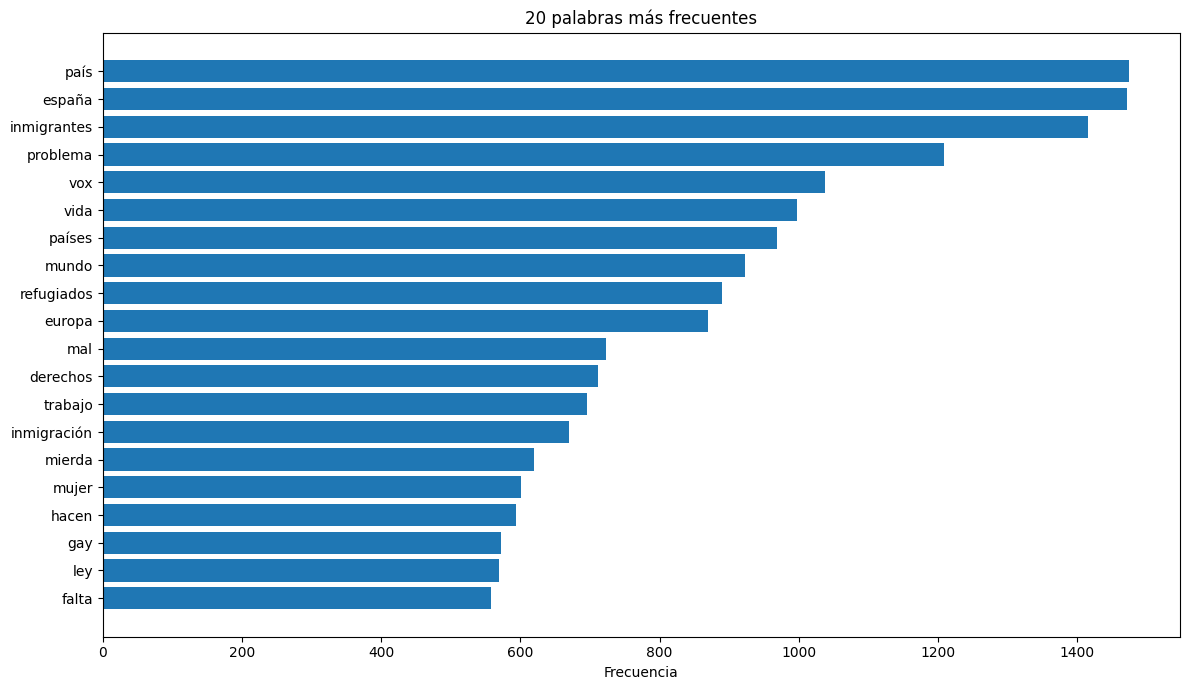

In [9]:
# ============================
# TOP 20 PALABRAS MÁS FRECUENTES
# ============================

top20 = frecuencia.head(20)

plt.figure(figsize=(12, 7))

plt.barh(
    top20["palabra"][::-1],
    top20["frecuencia"][::-1]
)

plt.title("20 palabras más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "01_top20_palabras.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Bloque 4 · Aplicación del diccionario de RRSS

In [10]:
# ============================
# IMPORTAR DICCIONARIO RRSS
# ============================

import importlib.util

ARCHIVO_DICCIONARIO_RRSS = (
    RUTA_DICCIONARIOS
    / "diccionario_rrss.py"
)

print("Diccionario:", ARCHIVO_DICCIONARIO_RRSS)
print("Existe:", ARCHIVO_DICCIONARIO_RRSS.exists())

if not ARCHIVO_DICCIONARIO_RRSS.exists():
    raise FileNotFoundError(
        f"No se encuentra: {ARCHIVO_DICCIONARIO_RRSS}"
    )

spec = importlib.util.spec_from_file_location(
    "diccionario_rrss",
    ARCHIVO_DICCIONARIO_RRSS
)

modulo_diccionario_rrss = (
    importlib.util.module_from_spec(spec)
)

spec.loader.exec_module(
    modulo_diccionario_rrss
)

analizar_comentario_rrss = (
    modulo_diccionario_rrss
    .analizar_comentario_rrss
)

print("Diccionario cargado correctamente.")

Diccionario: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\scripts\diccionarios\diccionario_rrss.py
Existe: True
Diccionario cargado correctamente.


In [11]:
# ============================
# ANÁLISIS DEL DICCIONARIO
# ============================

resultado = (
    comentarios["texto_lexico"]
    .apply(analizar_comentario_rrss)
    .apply(pd.Series)
)

comentarios = pd.concat(
    [comentarios, resultado],
    axis=1
)

print("Columnas añadidas:")
print(resultado.columns.tolist())

Columnas añadidas:
['nivel_xenofobia_rrss', 'nivel_lgtbifobia_rrss', 'terminos_xenofobia_rrss', 'terminos_lgtbifobia_rrss', 'count_xeno_neutro_rrss', 'count_xeno_conflicto_rrss', 'count_xeno_hostilidad_rrss', 'count_xeno_violencia_rrss', 'count_lgtbi_neutro_rrss', 'count_lgtbi_conflicto_rrss', 'count_lgtbi_hostilidad_rrss', 'count_lgtbi_violencia_rrss']


In [12]:
# ============================
# COMPROBACIÓN
# ============================

display(
    comentarios[
        [
            "texto_lexico",
            "nivel_xenofobia_rrss",
            "nivel_lgtbifobia_rrss"
        ]
    ].sample(15, random_state=42)
)

,texto_lexico,nivel_xenofobia_rrss,nivel_lgtbifobia_rrss
9857,joder imagina toca hígado encanta regaliz negro,sin_mencion,sin_mencion
22691,digi momento tenian ofrecian compañias sim dua...,sin_mencion,sin_mencion
19428,logros allá subida smi demás papel mojado lustro,sin_mencion,sin_mencion
16236,comenzado,sin_mencion,sin_mencion
4372,clavado dejar entrar refugiados siria sino lib...,neutro,sin_mencion
25197,propósito metafísica voy propósito metafísica ...,sin_mencion,sin_mencion
6663,debes gravisimo problema mental poblacion rusa...,hostilidad_explicita,sin_mencion
8610,información aporta asunto ocupa cuentes milong...,sin_mencion,sin_mencion
1103,tambien hablaba políticos permiten vender bomb...,sin_mencion,sin_mencion
17837,vuelve ferrovial,sin_mencion,sin_mencion


,nivel,comentarios,porcentaje
0,hostilidad_explicita,239,0.87
1,marco_conflictivo,909,3.31
2,neutro,3030,11.02
3,sin_mencion,23305,84.78
4,violencia_discriminacion,7,0.03


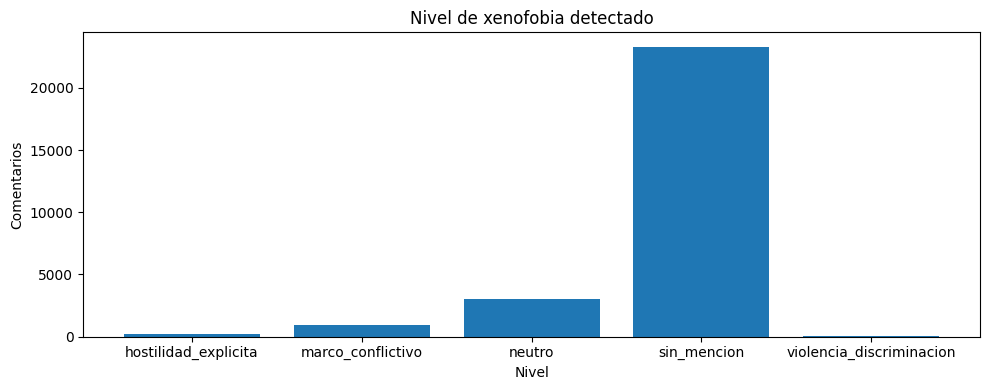

In [13]:
# ============================
# NIVELES DE XENOFOBIA
# ============================

niveles_xeno = (
    comentarios["nivel_xenofobia_rrss"]
    .value_counts()
    .sort_index()
    .reset_index()
)

niveles_xeno.columns = [
    "nivel",
    "comentarios"
]

niveles_xeno["porcentaje"] = (
    niveles_xeno["comentarios"]
    / len(comentarios)
    * 100
).round(2)

display(niveles_xeno)

niveles_xeno.to_csv(
    RUTA_TABLAS / "05_niveles_xenofobia.csv",
    index=False
)

plt.figure(figsize=(10,4))

plt.bar(
    niveles_xeno["nivel"],
    niveles_xeno["comentarios"]
)

plt.title("Nivel de xenofobia detectado")
plt.xlabel("Nivel")
plt.ylabel("Comentarios")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS /
    "05_niveles_xenofobia.png",
    dpi=300
)

plt.show()

,nivel,comentarios,porcentaje
0,hostilidad_explicita,228,0.83
1,marco_conflictivo,79,0.29
2,neutro,1895,6.89
3,sin_mencion,25001,90.95
4,violencia_discriminacion,287,1.04


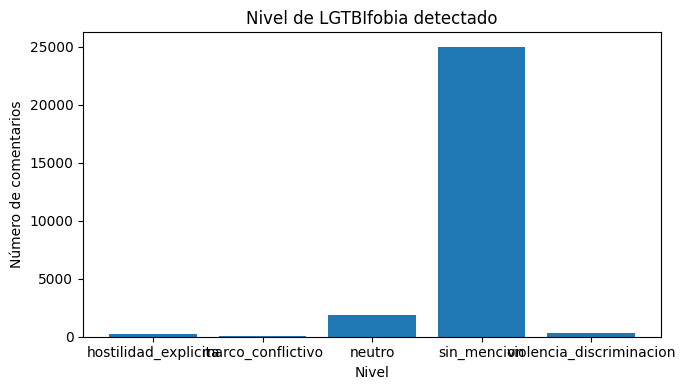

In [14]:
# ============================
# NIVELES DE LGTBIFOBIA
# ============================

niveles_lgtbi = (
    comentarios["nivel_lgtbifobia_rrss"]
    .value_counts()
    .sort_index()
    .reset_index()
)

niveles_lgtbi.columns = [
    "nivel",
    "comentarios"
]

niveles_lgtbi["porcentaje"] = (
    niveles_lgtbi["comentarios"]
    / len(comentarios)
    * 100
).round(2)

display(niveles_lgtbi)

# Guardar tabla
niveles_lgtbi.to_csv(
    RUTA_TABLAS / "06_niveles_lgtbifobia.csv",
    index=False
)

# Gráfico
plt.figure(figsize=(7, 4))

plt.bar(
    niveles_lgtbi["nivel"].astype(str),
    niveles_lgtbi["comentarios"]
)

plt.title("Nivel de LGTBIfobia detectado")
plt.xlabel("Nivel")
plt.ylabel("Número de comentarios")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "06_niveles_lgtbifobia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Bloque 5 · Visualización del vocabulario (WordCloud)

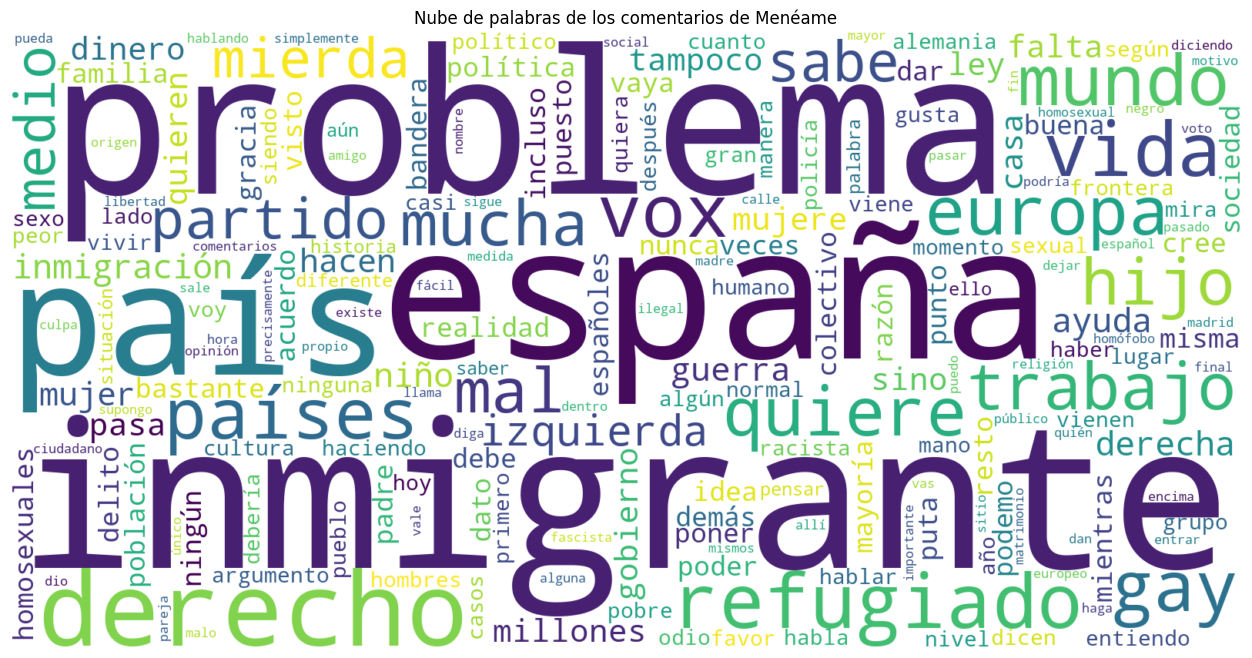

In [15]:
# ============================
# WORDCLOUD
# ============================

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    max_words=200,
    collocations=False,
    random_state=42
).generate(" ".join(comentarios["texto_lexico"]))

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de los comentarios de Menéame")

plt.savefig(
    RUTA_GRAFICOS / "02_wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Bloque 6· Análisis de sentimiento

In [16]:
# ============================
# ANALIZADOR DE SENTIMIENTO
# ============================

analyzer = create_analyzer(
    task="sentiment",
    lang="es"
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6222.50it/s]


In [17]:
# ============================
# ANÁLISIS DE SENTIMIENTO
# ============================

from tqdm.auto import tqdm

tqdm.pandas()


comentarios["sentimiento"] = comentarios["texto_analisis"].progress_apply(
    lambda x: analyzer.predict(str(x)).output
)

100%|██████████| 27490/27490 [19:48<00:00, 23.12it/s]


In [18]:
comentarios.to_csv(
    RUTA_PROCESADOS
    / "meneame_comentarios_analizados.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    comentarios[
        [
            "sentimiento",
            "nivel_xenofobia_rrss",
            "nivel_lgtbifobia_rrss"
        ]
    ].head()
)

  sentimiento nivel_xenofobia_rrss nivel_lgtbifobia_rrss
0         NEG               neutro           sin_mencion
1         NEG          sin_mencion           sin_mencion
2         NEU          sin_mencion           sin_mencion
3         NEG          sin_mencion           sin_mencion
4         NEU          sin_mencion                neutro


In [77]:
# ============================
# DISTRIBUCIÓN DEL SENTIMIENTO
# ============================

sentimiento = (
    comentarios["sentimiento"]
    .value_counts()
    .rename_axis("sentimiento")
    .reset_index(name="frecuencia")
)

sentimiento["porcentaje"] = (
    sentimiento["frecuencia"]
    / len(comentarios)
    * 100
).round(2)

display(sentimiento)

sentimiento.to_csv(
    RUTA_TABLAS / "02_sentimiento.csv",
    index=False
)

,sentimiento,frecuencia,porcentaje
0,NEG,18693,68.00
1,NEU,7403,26.93
2,POS,1394,5.07


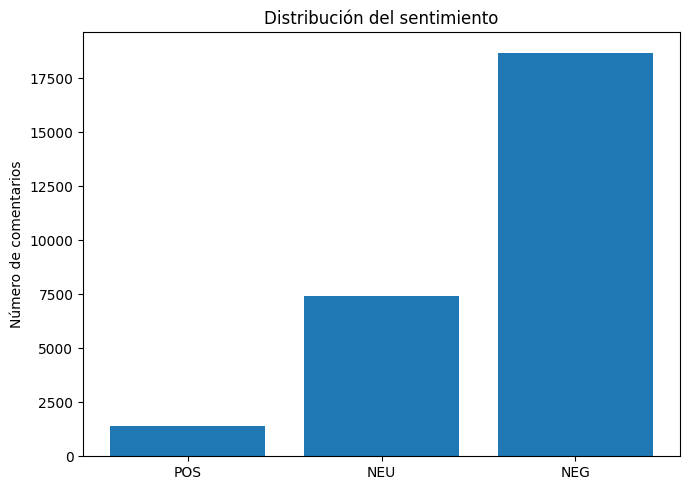

In [78]:
# ============================
# GRÁFICO DE SENTIMIENTO
# ============================

orden = ["POS", "NEU", "NEG"]

datos = (
    sentimiento
    .set_index("sentimiento")
    .reindex(orden)
    .dropna()
    .reset_index()
)

plt.figure(figsize=(7, 5))

plt.bar(
    datos["sentimiento"],
    datos["frecuencia"]
)

plt.title("Distribución del sentimiento")
plt.xlabel("")
plt.ylabel("Número de comentarios")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "03_sentimiento.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [79]:
# ============================
# SENTIMIENTO VS XENOFOBIA
# ============================

tabla_xeno = pd.crosstab(
    comentarios["nivel_xenofobia_rrss"],
    comentarios["sentimiento"],
    margins=True
)

display(tabla_xeno)

tabla_xeno.to_csv(
    RUTA_TABLAS / "09_sentimiento_vs_xenofobia.csv",
    encoding="utf-8-sig"
)

sentimiento,NEG,NEU,POS,All
nivel_xenofobia_rrss,,,,
hostilidad_explicita,199,35,5,239
marco_conflictivo,780,114,15,909
neutro,2464,509,57,3030
sin_mencion,15243,6745,1317,23305
violencia_discriminacion,7,0,0,7
All,18693,7403,1394,27490


In [80]:
# ============================
# SENTIMIENTO VS LGTBIFOBIA
# ============================

tabla_lgtbi = pd.crosstab(
    comentarios["nivel_lgtbifobia_rrss"],
    comentarios["sentimiento"],
    margins=True
)

display(tabla_lgtbi)

tabla_lgtbi.to_csv(
    RUTA_TABLAS / "09_sentimiento_vs_lgtbifobia.csv",
    encoding="utf-8-sig"
)

sentimiento,NEG,NEU,POS,All
nivel_lgtbifobia_rrss,,,,
hostilidad_explicita,198,25,5,228
marco_conflictivo,70,7,2,79
neutro,1505,346,44,1895
sin_mencion,16657,7005,1339,25001
violencia_discriminacion,263,20,4,287
All,18693,7403,1394,27490


In [81]:
# ============================
# PORCENTAJES XENOFOBIA
# ============================

tabla_xeno_pct = (
    pd.crosstab(
        comentarios["nivel_xenofobia_rrss"],
        comentarios["sentimiento"],
        normalize="index"
    ) * 100
).round(2)

display(tabla_xeno_pct)

tabla_xeno_pct.to_csv(
    RUTA_TABLAS / "09_sentimiento_vs_xenofobia_pct.csv",
    encoding="utf-8-sig"
)

sentimiento,NEG,NEU,POS
nivel_xenofobia_rrss,,,
hostilidad_explicita,83.26,14.64,2.09
marco_conflictivo,85.81,12.54,1.65
neutro,81.32,16.80,1.88
sin_mencion,65.41,28.94,5.65
violencia_discriminacion,100.00,0.00,0.00


In [82]:
# ============================
# PORCENTAJES LGTBIFOBIA
# ============================

tabla_lgtbi_pct = (
    pd.crosstab(
        comentarios["nivel_lgtbifobia_rrss"],
        comentarios["sentimiento"],
        normalize="index"
    ) * 100
).round(2)

display(tabla_lgtbi_pct)

tabla_lgtbi_pct.to_csv(
    RUTA_TABLAS / "09_sentimiento_vs_lgtbifobia_pct.csv",
    encoding="utf-8-sig"
)

sentimiento,NEG,NEU,POS
nivel_lgtbifobia_rrss,,,
hostilidad_explicita,86.84,10.96,2.19
marco_conflictivo,88.61,8.86,2.53
neutro,79.42,18.26,2.32
sin_mencion,66.63,28.02,5.36
violencia_discriminacion,91.64,6.97,1.39


In [83]:
# ============================
# CHI-CUADRADO Y V DE CRAMÉR
# XENOFOBIA
# ============================

from scipy.stats import chi2_contingency
import numpy as np

tabla = pd.crosstab(
    comentarios["nivel_xenofobia_rrss"],
    comentarios["sentimiento"]
)

chi2, p, dof, esperados = chi2_contingency(tabla)

n = tabla.to_numpy().sum()
k = min(tabla.shape)

cramers_v = np.sqrt(
    chi2 / (n * (k - 1))
)

print("=" * 50)
print("CHI-CUADRADO XENOFOBIA")
print("=" * 50)
print(f"χ² = {chi2:.3f}")
print(f"p-valor = {p:.8f}")
print(f"Grados de libertad = {dof}")
print(f"V de Cramér = {cramers_v:.3f}")

if p < 0.05:
    print("\n✅ Existe una asociación estadísticamente significativa.")
else:
    print("\n❌ No existe una asociación estadísticamente significativa.")

if cramers_v < 0.10:
    fuerza = "muy débil"
elif cramers_v < 0.30:
    fuerza = "débil"
elif cramers_v < 0.50:
    fuerza = "moderada"
else:
    fuerza = "fuerte"

print(f"Fuerza de la asociación: {fuerza}")

CHI-CUADRADO XENOFOBIA
χ² = 491.225
p-valor = 0.00000000
Grados de libertad = 8
V de Cramér = 0.095

✅ Existe una asociación estadísticamente significativa.
Fuerza de la asociación: muy débil


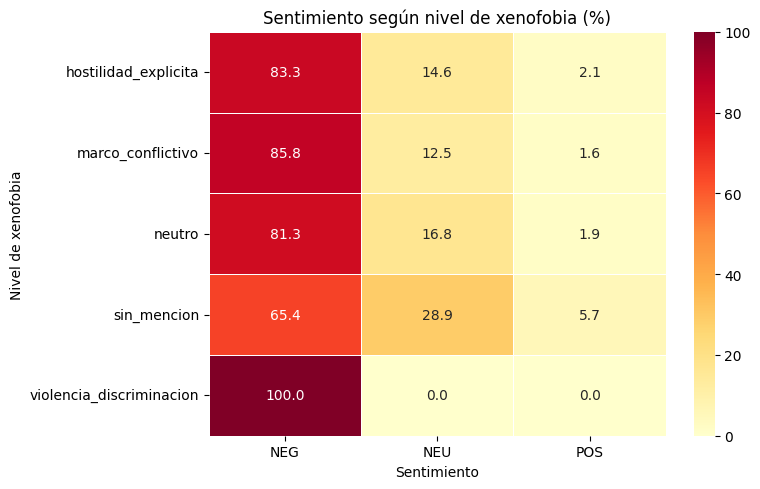

In [84]:
# ============================
# HEATMAP SENTIMIENTO VS XENOFOBIA
# ============================

import seaborn as sns

plt.figure(figsize=(8, 5))

sns.heatmap(
    tabla_xeno_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Sentimiento según nivel de xenofobia (%)")
plt.xlabel("Sentimiento")
plt.ylabel("Nivel de xenofobia")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "09_heatmap_sentimiento_xenofobia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [85]:
# ============================
# CHI-CUADRADO Y V DE CRAMÉR
# LGTBIFOBIA
# ============================

tabla = pd.crosstab(
    comentarios["nivel_lgtbifobia_rrss"],
    comentarios["sentimiento"]
)

chi2, p, dof, esperados = chi2_contingency(tabla)

n = tabla.to_numpy().sum()
k = min(tabla.shape)

cramers_v = np.sqrt(
    chi2 / (n * (k - 1))
)

print("=" * 50)
print("CHI-CUADRADO LGTBIFOBIA")
print("=" * 50)
print(f"χ² = {chi2:.3f}")
print(f"p-valor = {p:.8f}")
print(f"Grados de libertad = {dof}")
print(f"V de Cramér = {cramers_v:.3f}")

if p < 0.05:
    print("\n✅ Existe una asociación estadísticamente significativa.")
else:
    print("\n❌ No existe una asociación estadísticamente significativa.")

if cramers_v < 0.10:
    fuerza = "muy débil"
elif cramers_v < 0.30:
    fuerza = "débil"
elif cramers_v < 0.50:
    fuerza = "moderada"
else:
    fuerza = "fuerte"

print(f"Fuerza de la asociación: {fuerza}")

CHI-CUADRADO LGTBIFOBIA
χ² = 265.874
p-valor = 0.00000000
Grados de libertad = 8
V de Cramér = 0.070

✅ Existe una asociación estadísticamente significativa.
Fuerza de la asociación: muy débil


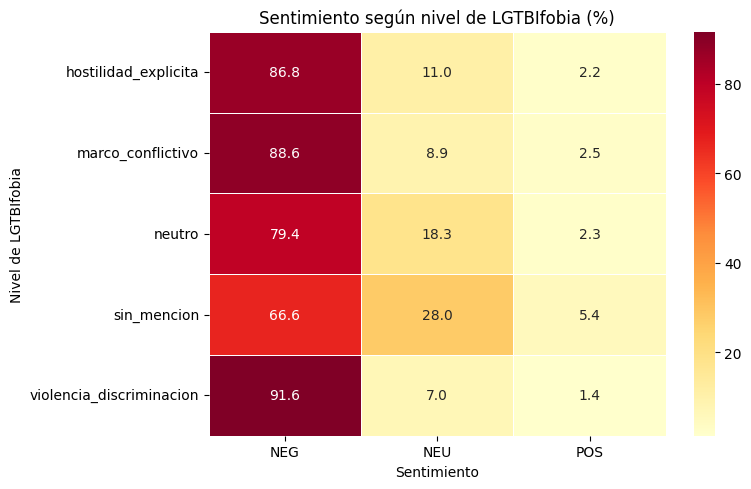

In [86]:
# ============================
# HEATMAP SENTIMIENTO VS LGTBIFOBIA
# ============================

plt.figure(figsize=(8, 5))

sns.heatmap(
    tabla_lgtbi_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Sentimiento según nivel de LGTBIfobia (%)")
plt.xlabel("Sentimiento")
plt.ylabel("Nivel de LGTBIfobia")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "09_heatmap_sentimiento_lgtbifobia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [87]:
# ============================
# XENOFOBIA SIN "SIN_MENCION"
# ============================

comentarios_xeno = comentarios[
    comentarios["nivel_xenofobia_rrss"] != "sin_mencion"
].copy()

tabla_xeno_filtrado = (
    pd.crosstab(
        comentarios_xeno["nivel_xenofobia_rrss"],
        comentarios_xeno["sentimiento"],
        normalize="index"
    ) * 100
).round(2)

display(tabla_xeno_filtrado)

tabla_xeno_filtrado.to_csv(
    RUTA_TABLAS / "09_sentimiento_vs_xenofobia_sin_mencion_pct.csv",
    encoding="utf-8-sig"
)

sentimiento,NEG,NEU,POS
nivel_xenofobia_rrss,,,
hostilidad_explicita,83.26,14.64,2.09
marco_conflictivo,85.81,12.54,1.65
neutro,81.32,16.80,1.88
violencia_discriminacion,100.00,0.00,0.00


In [88]:
# ============================
# LGTBIFOBIA SIN "SIN_MENCION"
# ============================

comentarios_lgtbi = comentarios[
    comentarios["nivel_lgtbifobia_rrss"] != "sin_mencion"
].copy()

tabla_lgtbi_filtrado = (
    pd.crosstab(
        comentarios_lgtbi["nivel_lgtbifobia_rrss"],
        comentarios_lgtbi["sentimiento"],
        normalize="index"
    ) * 100
).round(2)

display(tabla_lgtbi_filtrado)

tabla_lgtbi_filtrado.to_csv(
    RUTA_TABLAS / "09_sentimiento_vs_lgtbifobia_sin_mencion_pct.csv",
    encoding="utf-8-sig"
)

sentimiento,NEG,NEU,POS
nivel_lgtbifobia_rrss,,,
hostilidad_explicita,86.84,10.96,2.19
marco_conflictivo,88.61,8.86,2.53
neutro,79.42,18.26,2.32
violencia_discriminacion,91.64,6.97,1.39


In [89]:
# ============================
# RESUMEN DE PRUEBAS ESTADÍSTICAS
# ============================

def calcular_asociacion(dataframe, variable, nombre):

    tabla = pd.crosstab(
        dataframe[variable],
        dataframe["sentimiento"]
    )

    chi2, p, dof, esperados = chi2_contingency(tabla)

    n = tabla.to_numpy().sum()
    k = min(tabla.shape)

    v_cramer = np.sqrt(
        chi2 / (n * (k - 1))
    )

    if v_cramer < 0.10:
        fuerza = "muy débil"
    elif v_cramer < 0.30:
        fuerza = "débil"
    elif v_cramer < 0.50:
        fuerza = "moderada"
    else:
        fuerza = "fuerte"

    return {
        "comparacion": nombre,
        "n_comentarios": n,
        "chi2": round(chi2, 3),
        "p_valor": p,
        "grados_libertad": dof,
        "v_cramer": round(v_cramer, 3),
        "significativa": "Sí" if p < 0.05 else "No",
        "fuerza_asociacion": fuerza
    }


resultados_estadisticos = [
    calcular_asociacion(
        comentarios,
        "nivel_xenofobia_rrss",
        "Sentimiento vs Xenofobia"
    ),

    calcular_asociacion(
        comentarios_xeno,
        "nivel_xenofobia_rrss",
        "Sentimiento vs Xenofobia (sin sin_mencion)"
    ),

    calcular_asociacion(
        comentarios,
        "nivel_lgtbifobia_rrss",
        "Sentimiento vs LGTBIfobia"
    ),

    calcular_asociacion(
        comentarios_lgtbi,
        "nivel_lgtbifobia_rrss",
        "Sentimiento vs LGTBIfobia (sin sin_mencion)"
    )
]

estadisticos = pd.DataFrame(resultados_estadisticos)

display(estadisticos)

estadisticos.to_csv(
    RUTA_TABLAS / "09_pruebas_estadisticas.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Pruebas estadísticas exportadas correctamente.")

,comparacion,n_comentarios,chi2,p_valor,grados_libertad,v_cramer,significativa,fuerza_asociacion
0,Sentimiento vs Xenofobia,27490,491.225,5.366582e-101,8,0.095,Sí,muy débil
1,Sentimiento vs Xenofobia (sin sin_mencion),4185,11.771,6.727379e-02,6,0.038,No,muy débil
2,Sentimiento vs LGTBIfobia,27490,265.874,7.391913e-53,8,0.070,Sí,muy débil
3,Sentimiento vs LGTBIfobia (sin sin_mencion),2489,33.692,7.713106e-06,6,0.082,Sí,muy débil


Pruebas estadísticas exportadas correctamente.


# Bloque 7 · Bigramas

In [90]:
# ============================
# BIGRAMAS MÁS FRECUENTES
# ============================

from sklearn.feature_extraction.text import CountVectorizer

vectorizador_bigramas = CountVectorizer(
    ngram_range=(2, 2),
    min_df=5
)

matriz_bigramas = vectorizador_bigramas.fit_transform(
    comentarios["texto_lexico"].fillna("")
)

frecuencias_bigramas = matriz_bigramas.sum(axis=0).A1
nombres_bigramas = vectorizador_bigramas.get_feature_names_out()

bigramas = (
    pd.DataFrame({
        "bigrama": nombres_bigramas,
        "frecuencia": frecuencias_bigramas
    })
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)

display(bigramas.head(30))

,bigrama,frecuencia
0,extrema derecha,170
1,derechos humanos,142
2,orientación sexual,137
3,mano obra,97
4,inmigrantes ilegales,90
5,inmigración ilegal,87
6,efecto llamada,74
7,muchas veces,73
8,reino unido,69
9,punto vista,67


In [91]:
# ============================
# EXPORTAR BIGRAMAS
# ============================

bigramas.to_csv(
    RUTA_TABLAS / "10_bigramas.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Bigramas exportados correctamente.")

Bigramas exportados correctamente.


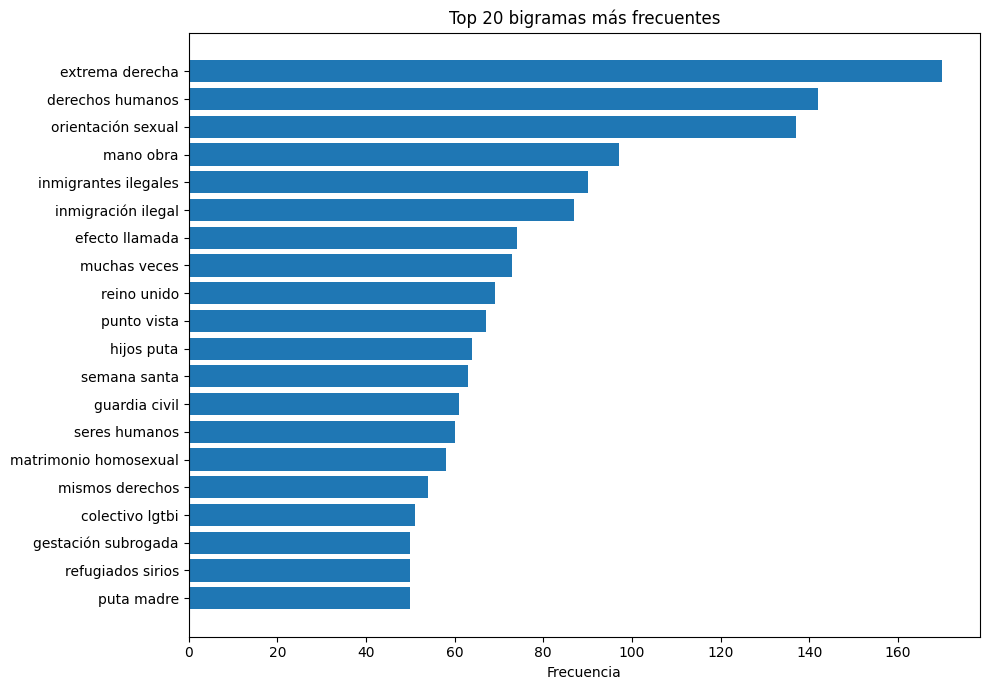

In [92]:
# ============================
# GRÁFICO TOP 20 BIGRAMAS
# ============================

top20_bigramas = bigramas.head(20).sort_values(
    "frecuencia",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top20_bigramas["bigrama"],
    top20_bigramas["frecuencia"]
)

plt.title("Top 20 bigramas más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "10_top20_bigramas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Bloque 8 · Trigramas

In [93]:
# ============================
# TRIGRAMAS MÁS FRECUENTES
# ============================

from sklearn.feature_extraction.text import CountVectorizer

vectorizador_trigramas = CountVectorizer(
    ngram_range=(3, 3),
    min_df=5
)

matriz_trigramas = vectorizador_trigramas.fit_transform(
    comentarios["texto_lexico"].fillna("")
)

frecuencias_trigramas = matriz_trigramas.sum(axis=0).A1
nombres_trigramas = vectorizador_trigramas.get_feature_names_out()

trigramas = (
    pd.DataFrame({
        "trigrama": nombres_trigramas,
        "frecuencia": frecuencias_trigramas
    })
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)

display(trigramas.head(30))

,trigrama,frecuencia
0,mano obra barata,37
1,bla bla bla,18
2,ayyy ignore próxima,12
3,comentarios encontrado media,12
4,revisando fondo comentarios,12
5,asco revisando fondo,12
6,encontrado media neurona,12
7,lloricona supongo defensa,12
8,madre ayyy ignore,12
9,lloriquear lloricona supongo,12


In [94]:
# ============================
# EXPORTAR TRIGRAMAS
# ============================

trigramas.to_csv(
    RUTA_TABLAS / "11_trigramas.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Trigramas exportados correctamente.")

Trigramas exportados correctamente.


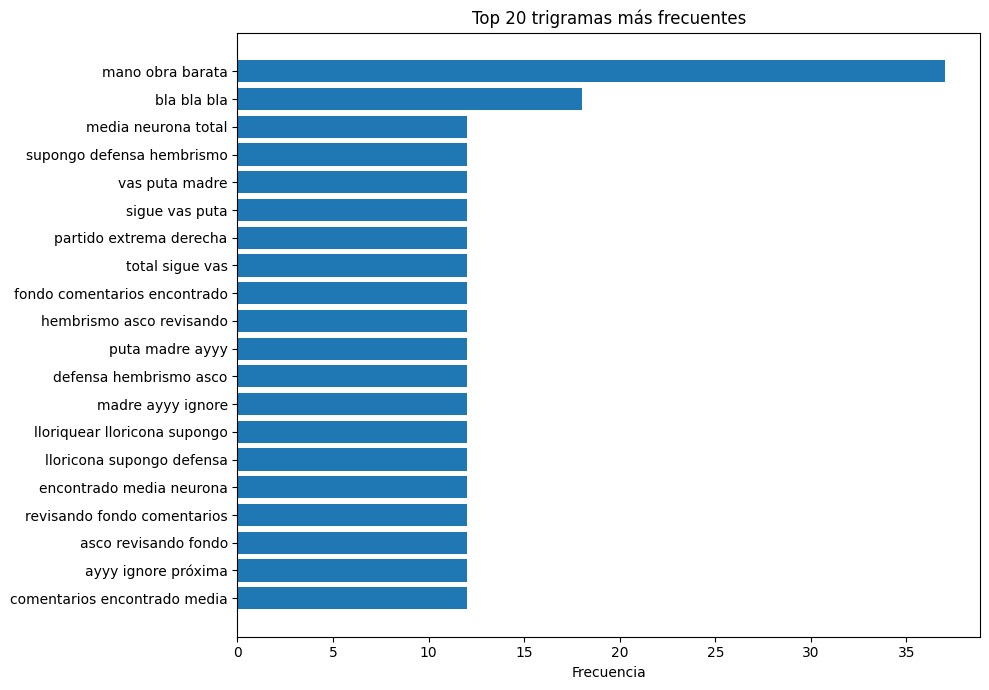

In [95]:
# ============================
# TOP 20 TRIGRAMAS
# ============================

top20_trigramas = trigramas.head(20).sort_values(
    "frecuencia",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top20_trigramas["trigrama"],
    top20_trigramas["frecuencia"]
)

plt.title("Top 20 trigramas más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "11_top20_trigramas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Bloque 9 · Modelado de temas (BERTopic)

In [11]:
# ============================
# PREPARAR TEXTOS PARA BERTOPIC
# ============================

documentos = (
    comentarios["texto_analisis"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Eliminar textos vacíos o demasiado cortos
mascara_bertopic = documentos.str.len() >= 20

documentos_bertopic = documentos[mascara_bertopic].tolist()
indices_bertopic = comentarios.index[mascara_bertopic]

print(f"Comentarios totales: {len(comentarios):,}")
print(f"Comentarios utilizados en BERTopic: {len(documentos_bertopic):,}")

Comentarios totales: 27,490
Comentarios utilizados en BERTopic: 26,271


In [15]:
# ============================
# CONFIGURACIÓN DE BERTOPIC
# ============================

modelo_embeddings = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

modelo_umap = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

modelo_hdbscan = HDBSCAN(
    min_cluster_size=50,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

stopwords_bertopic_extra = {
    "lol",
    "grin",
    "troll",
    "https",
    "http",
    "www",
    "net",
    "meneame",
    "com",
    "story",
    "watch",
    "youtube",
    "youtu",
    "youtu be",
    "video",
    "vídeo",
    "gracias",
    "va",
    "da"
}

stopwords_bertopic = stopwords_totales.union(
    stopwords_bertopic_extra
)

vectorizador_bertopic = CountVectorizer(
    stop_words=list(stopwords_bertopic),
    ngram_range=(1, 2),
    min_df=5
)

modelo_bertopic = BERTopic(
    embedding_model=modelo_embeddings,
    umap_model=modelo_umap,
    hdbscan_model=modelo_hdbscan,
    vectorizer_model=vectorizador_bertopic,
    language="multilingual",
    calculate_probabilities=False,
    verbose=True
)

print("Modelo BERTopic configurado correctamente.")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10580.00it/s]


Modelo BERTopic configurado correctamente.


In [17]:
# ============================
# ENTRENAMIENTO DE BERTOPIC
# ============================

topics, probabilities = modelo_bertopic.fit_transform(
    documentos_bertopic
)

print("BERTopic finalizado.")
print(f"Número de documentos procesados: {len(topics):,}")

2026-07-24 23:26:58,494 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 821/821 [02:42<00:00,  5.05it/s]
2026-07-24 23:29:41,221 - BERTopic - Embedding - Completed ✓
2026-07-24 23:29:41,223 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-24 23:30:05,568 - BERTopic - Dimensionality - Completed ✓
2026-07-24 23:30:05,569 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-24 23:30:07,209 - BERTopic - Cluster - Completed ✓
2026-07-24 23:30:07,213 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-24 23:30:07,878 - BERTopic - Representation - Completed ✓


BERTopic finalizado.
Número de documentos procesados: 26,271


In [18]:
# ============================
# RESUMEN DE TEMAS
# ============================

temas = modelo_bertopic.get_topic_info()

display(temas.head(20))

temas.to_csv(
    RUTA_TABLAS / "12_bertopic_temas.csv",
    index=False,
    encoding="utf-8-sig"
)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,9171,-1_españa_país_europa_países,"[españa, país, europa, países, inmigrantes, pr...",[¿ficción jurídica? Esto qué es. Estoy diciend...
1,0,5100,0_datos_mierda_comentarios_razón,"[datos, mierda, comentarios, razón, voy, vida,...","[Estamos hablando de tener estudios, es eviden..."
2,1,1821,1_inmigrantes_inmigración_ayudas_trabajo,"[inmigrantes, inmigración, ayudas, trabajo, in...",[La solución no es sostenible. ¿Luego cómo se ...
3,2,1672,2_vox_partido_izquierda_pp,"[vox, partido, izquierda, pp, votar, derechos,...","[Otro ""demócrata"" reportado... Vox {0x1f49a} {..."
4,3,744,3_gay_gays_homofobia_homosexuales,"[gay, gays, homofobia, homosexuales, homosexua...",[¿y? Hay homosexuales en contra del matrimonio...
5,4,578,4_religión_iglesia_dios_religiones,"[religión, iglesia, dios, religiones, cristian...",[yo soy ateo y repudio las religiones por igua...
6,5,568,5_policía_delito_juez_ley,"[policía, delito, juez, ley, guardia, cárcel, ...",[Pero lo importante es la denuncia a la policí...
7,6,408,6_noticias_periodista_titular_medios,"[noticias, periodista, titular, medios, fake, ...","[Sobre la discusión de que medio elegir, creo ..."
8,7,364,7_racista_racistas_racismo_negros,"[racista, racistas, racismo, negros, raza, neg...","[Eres un racista y lo sabes., que racista es l..."
9,8,343,8_españa_españoles_inmigrantes_trabajo,"[españa, españoles, inmigrantes, trabajo, mill...","[Te has hecho un lío. Aquí no se habla de ""met..."


In [20]:
# ============================
# AÑADIR TOPIC AL DATAFRAME
# ============================

comentarios["topic"] = -1

comentarios.loc[
    indices_bertopic,
    "topic"
] = topics

comentarios["topic"] = (
    comentarios["topic"]
    .astype(int)
)

comentarios.to_csv(
    RUTA_PROCESADOS
    / "meneame_comentarios_analizados.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Topics asignados correctamente.")

print(
    comentarios["topic"]
    .value_counts()
    .sort_index()
)

Topics asignados correctamente.
topic
-1     10390
 0      5100
 1      1821
 2      1672
 3       744
 4       578
 5       568
 6       408
 7       364
 8       343
 9       342
 10      316
 11      274
 12      255
 13      224
 14      222
 15      214
 16      199
 17      188
 18      172
 19      168
 20      167
 21      152
 22      146
 23      145
 24      129
 25      121
 26      119
 27      118
 28      110
 29      106
 30      103
 31      102
 32      101
 33       97
 34       97
 35       97
 36       94
 37       93
 38       93
 39       86
 40       85
 41       84
 42       83
 43       79
 44       78
 45       65
 46       62
 47       61
 48       55
Name: count, dtype: int64


In [21]:
# ============================
# DISTRIBUCIÓN DE TEMAS
# ============================

topicos = (
    comentarios["topic"]
    .value_counts()
    .sort_index()
    .reset_index()
)

topicos.columns = [
    "topic",
    "comentarios"
]

display(topicos)

topicos.to_csv(
    RUTA_TABLAS / "12_distribucion_topics.csv",
    index=False,
    encoding="utf-8-sig"
)

,topic,comentarios
0,-1,10390
1,0,5100
2,1,1821
3,2,1672
4,3,744
5,4,578
6,5,568
7,6,408
8,7,364
9,8,343


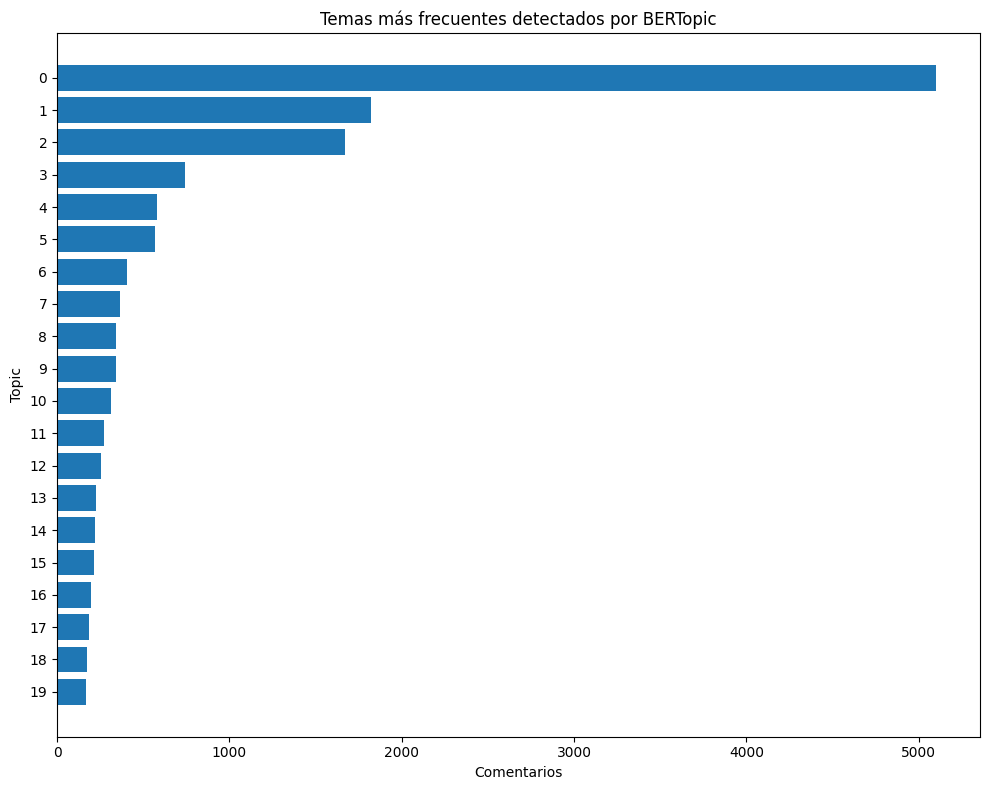

In [22]:
# ============================
# TOP 20 TEMAS
# ============================

top20 = (
    topicos
    .query("topic != -1")
    .sort_values("comentarios", ascending=False)
    .head(20)
    .sort_values("comentarios")
)

plt.figure(figsize=(10,8))

plt.barh(
    top20["topic"].astype(str),
    top20["comentarios"]
)

plt.title("Temas más frecuentes detectados por BERTopic")
plt.xlabel("Comentarios")
plt.ylabel("Topic")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "12_top_topics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
temas.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,9171,-1_españa_país_europa_países,"[españa, país, europa, países, inmigrantes, pr...",[¿ficción jurídica? Esto qué es. Estoy diciend...
1,0,5100,0_datos_mierda_comentarios_razón,"[datos, mierda, comentarios, razón, voy, vida,...","[Estamos hablando de tener estudios, es eviden..."
2,1,1821,1_inmigrantes_inmigración_ayudas_trabajo,"[inmigrantes, inmigración, ayudas, trabajo, in...",[La solución no es sostenible. ¿Luego cómo se ...
3,2,1672,2_vox_partido_izquierda_pp,"[vox, partido, izquierda, pp, votar, derechos,...","[Otro ""demócrata"" reportado... Vox {0x1f49a} {..."
4,3,744,3_gay_gays_homofobia_homosexuales,"[gay, gays, homofobia, homosexuales, homosexua...",[¿y? Hay homosexuales en contra del matrimonio...
5,4,578,4_religión_iglesia_dios_religiones,"[religión, iglesia, dios, religiones, cristian...",[yo soy ateo y repudio las religiones por igua...
6,5,568,5_policía_delito_juez_ley,"[policía, delito, juez, ley, guardia, cárcel, ...",[Pero lo importante es la denuncia a la policí...
7,6,408,6_noticias_periodista_titular_medios,"[noticias, periodista, titular, medios, fake, ...","[Sobre la discusión de que medio elegir, creo ..."
8,7,364,7_racista_racistas_racismo_negros,"[racista, racistas, racismo, negros, raza, neg...","[Eres un racista y lo sabes., que racista es l..."
9,8,343,8_españa_españoles_inmigrantes_trabajo,"[españa, españoles, inmigrantes, trabajo, mill...","[Te has hecho un lío. Aquí no se habla de ""met..."


In [25]:
# ============================
# RESUMEN DE TOPICS
# ============================

temas = modelo_bertopic.get_topic_info()

temas["Porcentaje"] = (
    temas["Count"]
    / temas["Count"].sum()
    * 100
).round(2)

display(temas)

temas.to_csv(
    RUTA_TABLAS / "12_resumen_topics.csv",
    index=False,
    encoding="utf-8-sig"
)

,Topic,Count,Name,Representation,Representative_Docs,Porcentaje
0,-1,9171,-1_españa_país_europa_países,"[españa, país, europa, países, inmigrantes, pr...",[¿ficción jurídica? Esto qué es. Estoy diciend...,34.91
1,0,5100,0_datos_mierda_comentarios_razón,"[datos, mierda, comentarios, razón, voy, vida,...","[Estamos hablando de tener estudios, es eviden...",19.41
2,1,1821,1_inmigrantes_inmigración_ayudas_trabajo,"[inmigrantes, inmigración, ayudas, trabajo, in...",[La solución no es sostenible. ¿Luego cómo se ...,6.93
3,2,1672,2_vox_partido_izquierda_pp,"[vox, partido, izquierda, pp, votar, derechos,...","[Otro ""demócrata"" reportado... Vox {0x1f49a} {...",6.36
4,3,744,3_gay_gays_homofobia_homosexuales,"[gay, gays, homofobia, homosexuales, homosexua...",[¿y? Hay homosexuales en contra del matrimonio...,2.83
5,4,578,4_religión_iglesia_dios_religiones,"[religión, iglesia, dios, religiones, cristian...",[yo soy ateo y repudio las religiones por igua...,2.20
6,5,568,5_policía_delito_juez_ley,"[policía, delito, juez, ley, guardia, cárcel, ...",[Pero lo importante es la denuncia a la policí...,2.16
7,6,408,6_noticias_periodista_titular_medios,"[noticias, periodista, titular, medios, fake, ...","[Sobre la discusión de que medio elegir, creo ...",1.55
8,7,364,7_racista_racistas_racismo_negros,"[racista, racistas, racismo, negros, raza, neg...","[Eres un racista y lo sabes., que racista es l...",1.39
9,8,343,8_españa_españoles_inmigrantes_trabajo,"[españa, españoles, inmigrantes, trabajo, mill...","[Te has hecho un lío. Aquí no se habla de ""met...",1.31


In [26]:
# ============================
# COMENTARIOS REPRESENTATIVOS
# ============================

representativos = []

for topic in temas["Topic"]:

    if topic == -1:
        continue

    docs = modelo_bertopic.get_representative_docs(topic)

    if docs is None:
        continue

    for i, doc in enumerate(docs[:3], start=1):

        representativos.append({
            "topic": topic,
            "ejemplo": i,
            "comentario": doc
        })

representativos = pd.DataFrame(representativos)

display(representativos.head(20))

representativos.to_csv(
    RUTA_TABLAS / "12_comentarios_representativos.csv",
    index=False,
    encoding="utf-8-sig"
)

,topic,ejemplo,comentario
0,0,1,"Estamos hablando de tener estudios, es evident..."
1,0,2,"lo de Mia Farrow es terrorifico, adopto 10 hij..."
2,0,3,"NO tienes verguenza , pero gracias, asi la gen..."
3,1,1,La solución no es sostenible. ¿Luego cómo se s...
4,1,2,JJojojojojojjajajajajajajjojojojojojo. A los q...
5,1,3,Como Idi Amin con los inmigrantes asiáticos
6,2,1,"Otro ""demócrata"" reportado... Vox {0x1f49a} {0..."
7,2,2,"El país de la libertad, los derechos y la demo..."
8,2,3,yo hablo por mí en esto Soy más de izquierdas ...
9,3,1,¿y? Hay homosexuales en contra del matrimonio ...


In [27]:
# ============================
# PALABRAS CLAVE POR TOPIC
# ============================

palabras_topic = []

for topic in temas["Topic"]:

    if topic == -1:
        continue

    palabras = modelo_bertopic.get_topic(topic)

    palabras_topic.append({
        "topic": topic,
        "palabras_clave": ", ".join(
            palabra
            for palabra, _ in palabras[:10]
        )
    })

palabras_topic = pd.DataFrame(palabras_topic)

display(palabras_topic)

palabras_topic.to_csv(
    RUTA_TABLAS / "12_palabras_clave_topics.csv",
    index=False,
    encoding="utf-8-sig"
)

,topic,palabras_clave
0,0,"datos, mierda, comentarios, razón, voy, vida, ..."
1,1,"inmigrantes, inmigración, ayudas, trabajo, inm..."
2,2,"vox, partido, izquierda, pp, votar, derechos, ..."
3,3,"gay, gays, homofobia, homosexuales, homosexual..."
4,4,"religión, iglesia, dios, religiones, cristiano..."
5,5,"policía, delito, juez, ley, guardia, cárcel, v..."
6,6,"noticias, periodista, titular, medios, fake, a..."
7,7,"racista, racistas, racismo, negros, raza, negr..."
8,8,"españa, españoles, inmigrantes, trabajo, millo..."
9,9,"musulmanes, islam, musulmán, musulmana, terror..."


In [28]:
# ============================
# RESUMEN FINAL DE TOPICS
# ============================

resumen_topics = (
    temas[["Topic", "Count", "Porcentaje"]]
    .merge(
        palabras_topic,
        left_on="Topic",
        right_on="topic",
        how="left"
    )
    .drop(columns="topic")
)

display(resumen_topics)

resumen_topics.to_csv(
    RUTA_TABLAS / "12_resumen_final_topics.csv",
    index=False,
    encoding="utf-8-sig"
)

,Topic,Count,Porcentaje,palabras_clave
0,-1,9171,34.91,NaN
1,0,5100,19.41,"datos, mierda, comentarios, razón, voy, vida, ..."
2,1,1821,6.93,"inmigrantes, inmigración, ayudas, trabajo, inm..."
3,2,1672,6.36,"vox, partido, izquierda, pp, votar, derechos, ..."
4,3,744,2.83,"gay, gays, homofobia, homosexuales, homosexual..."
5,4,578,2.20,"religión, iglesia, dios, religiones, cristiano..."
6,5,568,2.16,"policía, delito, juez, ley, guardia, cárcel, v..."
7,6,408,1.55,"noticias, periodista, titular, medios, fake, a..."
8,7,364,1.39,"racista, racistas, racismo, negros, raza, negr..."
9,8,343,1.31,"españa, españoles, inmigrantes, trabajo, millo..."


In [29]:
etiquetas_topics = {
    1: "España e identidad",
    2: "Inmigración y ayudas",
    3: "VOX y política",
    4: "Homosexualidad",
    5: "Religión",
    6: "Islam",
    7: "Racismo",
    8: "Refugiados",
    10: "Europa",
    11: "Policía y delitos",
    12: "Marruecos",
    13: "Llegadas por mar",
    14: "África",
    15: "Infancia",
    16: "Siria"
}

topics_excluir = [-1, 0, 9]

top_temas_limpios = (
    resumen_topics[
        ~resumen_topics["Topic"].isin(topics_excluir)
    ]
    .sort_values("Count", ascending=False)
    .head(15)
    .sort_values("Count", ascending=True)
    .copy()
)

top_temas_limpios["tema"] = (
    top_temas_limpios["Topic"]
    .map(etiquetas_topics)
)

display(top_temas_limpios)

,Topic,Count,Porcentaje,palabras_clave,tema
17,16,199,0.76,"padres, niños, niño, hijos, edad, padre, hijo,...",Siria
16,15,214,0.81,"marruecos, libia, marroquí, marroquíes, túnez,...",Infancia
15,14,222,0.85,"barco, puerto, mar, barcos, embarcaciones, bal...",África
14,13,224,0.85,"españa, españoles, español, espana, española, ...",Llegadas por mar
13,12,255,0.97,"europa, ue, hungría, europeos, unión, europea,...",Marruecos
12,11,274,1.04,"html, be, old, jpg, org, eldiario, search, org...",Policía y delitos
11,10,316,1.20,"refugiados, refugiado, sirios, refugiados siri...",Europa
9,8,343,1.31,"españa, españoles, inmigrantes, trabajo, millo...",Refugiados
8,7,364,1.39,"racista, racistas, racismo, negros, raza, negr...",Racismo
7,6,408,1.55,"noticias, periodista, titular, medios, fake, a...",Islam


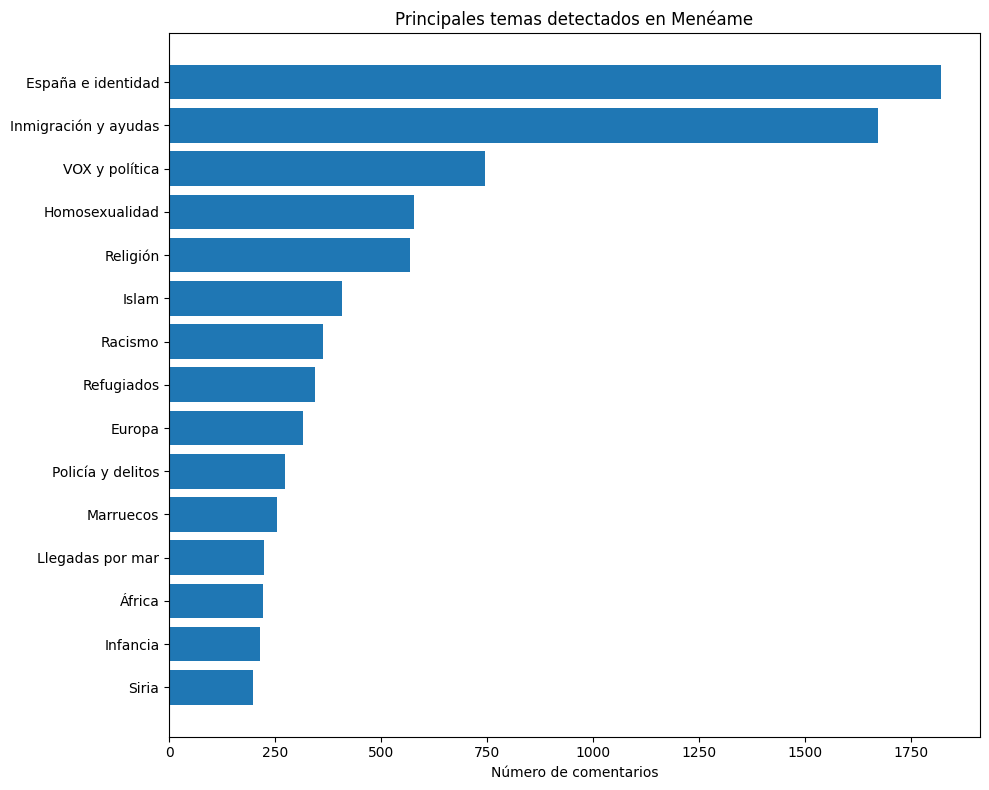

In [30]:
# ============================
# TOP TEMAS INTERPRETABLES
# ============================

plt.figure(figsize=(10, 8))

plt.barh(
    top_temas_limpios["tema"],
    top_temas_limpios["Count"]
)

plt.title("Principales temas detectados en Menéame")
plt.xlabel("Número de comentarios")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "12_top_topics_interpretables.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()